# Authors 
## Group ID: 4

# Notes Before Review - first note is a link to our github repository

Dear Professor,

Before diving into our notebook, here are a few key notes regarding our submission:

- **Modular Codebase**  
   All algorithms and utilities are structured for clarity and reuse. Our codebase is organized in a modular fashion and available on GitHub under the `rl_homework2` folder in our repository [Github repository](https://github.com/RyanWri/afeka-homework/tree/main/rl_homework_2).

- **Chosen Environment – GridWorld**  
   We selected a custom 5×5 GridWorld environment with obstacles and goal states. The environment was implemented fully from scratch, following the **OpenAI Gym interface** standards to ensure consistency, modularity, and reproducibility.

- **Group Coordination (Group ID: 4)**  
   Our group was the **first to complete** the assignment. In coordination with the rest of the class, we agreed not to share this environment design to avoid collisions across submissions. This ensures originality and fairness.

- **Comprehensive Final Report**  
   The last section of this notebook presents a **detailed comparative report** addressing all questions from the assignment. It includes algorithm-level insights and distilled conclusions grounded in empirical results.

- **Visualizations & Performance Tracking**  
   Value functions, Q-maps, reward curves, and greedy policy arrows are visualized **throughout the notebook**. Each algorithm includes runtime, convergence behavior, and policy evaluation metrics.

Thank you for your time and consideration.

— Group 4

In [1]:
import numpy as np
from grid_world import GridWorldEnv
from dynamic_programming import value_iteration
from mdp import extract_mdp

# Create Grid World Environment

In [2]:
# Create new environment with (row, col) coordinates
env = GridWorldEnv(rows=5, cols=5, obstacles={(1, 1), (2, 2), (3, 1)})

### Markov Decision Process
we want to get the states, actios and transition probabilites

In [3]:
states, actions, transition_probabilites = extract_mdp(env)

## Algorithms

## Dynamic Programming using Value iteration

Converged in 89 iterations, time = 0.006s
DP avg reward over 500 eval episodes: 0.93


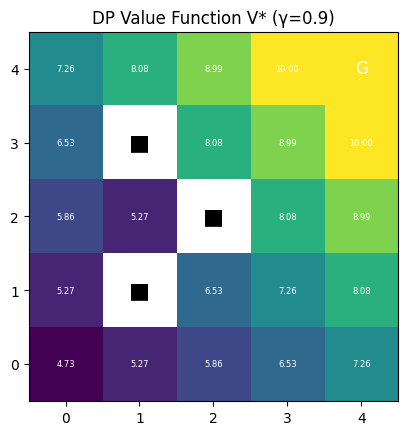

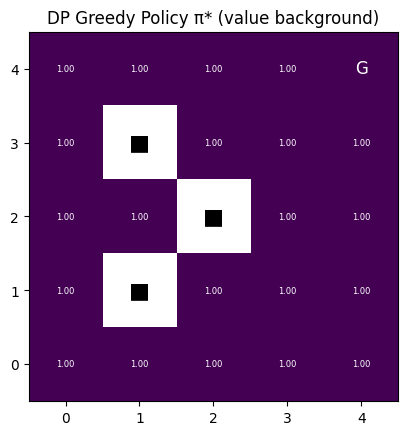

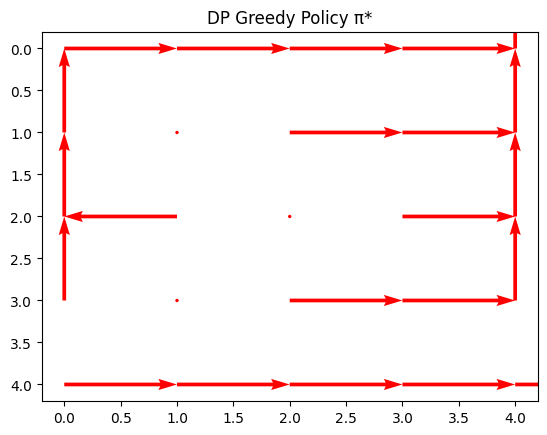

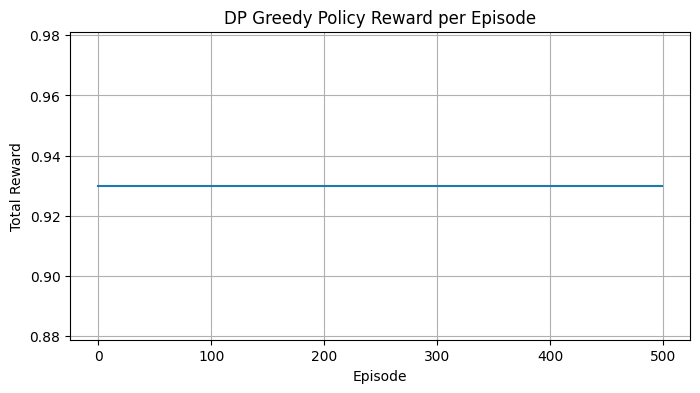

In [4]:
import time
from utils import (
    RLConfig,
    RLResult,
    plot_value_function,
    plot_policy_arrows_from_q,
    record_episode_metrics,
    plot_episode_rewards,
)

config = RLConfig(gamma=0.9)  # use γ=0.9 as per assignment
# We'll evaluate policies for: DP, Q-Learning, SARSA, TD(λ)
eval_config = RLConfig(episodes=500, max_steps=100)

start_time = time.time()
V_opt, pi_opt, iterations = value_iteration(
    states, actions, transition_probabilites, gamma=config.gamma, theta=1e-4
)
elapsed = time.time() - start_time

result_dp = RLResult(
    name="Value Iteration (DP)",
    time_seconds=elapsed,
    iterations=iterations,
    value_function=V_opt,
    policy=pi_opt,
    notes="Converged using full environment model",
)

# 1) Value Iteration policy
dp_policy = lambda s: result_dp.policy[s]
dp_rewards, _, _ = record_episode_metrics(env, dp_policy, eval_config)
result_dp.rewards_per_episode = dp_rewards

print(
    f"Converged in {result_dp.iterations} iterations, time = {result_dp.time_seconds:.3f}s"
)
print(
    f"DP avg reward over {eval_config.episodes} eval episodes: {np.mean(dp_rewards):.2f}"
)


# 3) Plot the optimal value function
plot_value_function(
    result_dp.value_function, env, title=f"DP Value Function V* (γ={config.gamma})"
)

# 4) Plot the greedy policy π* using our arrow‐plotting utility
#    We turn π into a “dummy Q” so we can reuse plot_policy_arrows_from_q:
Q_dummy = {
    (s, a): 1.0 if a == result_dp.policy[s] else 0.0 for s in states for a in actions
}
plot_policy_arrows_from_q(Q_dummy, env, title="DP Greedy Policy π*")

plot_episode_rewards(dp_rewards, title="DP Greedy Policy Reward per Episode")
# └───────────────────────────────────────────────────────────────────────────────

## Monte Carlo Methods - using random policy

Completed in 1000 episodes, time = 0.087s


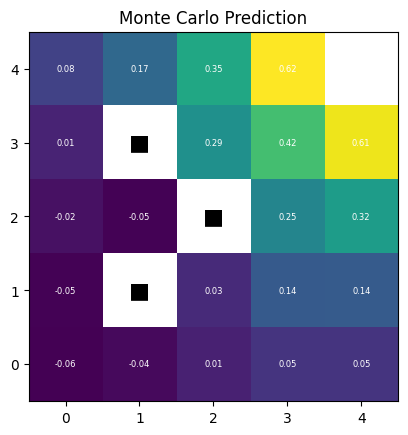

In [5]:
from monte_carlo import monte_carlo_prediction, random_policy_factory

# 1) Configure parameters
config = RLConfig(gamma=0.9, episodes=1000, max_steps=100)
random_policy = random_policy_factory(env.action_space)

# 2) Run Monte Carlo Prediction
start_time = time.time()
V_mc = monte_carlo_prediction(
    env, policy=random_policy, num_episodes=config.episodes, gamma=config.gamma
)
elapsed = time.time() - start_time

# 3) Store result
result_mc = RLResult(
    name="Monte Carlo Prediction",
    time_seconds=elapsed,
    iterations=config.episodes,
    value_function=V_mc,
    notes="First-visit MC with random policy over 1000 episodes",
)

print(
    f"Completed in {result_mc.iterations} episodes, time = {result_mc.time_seconds:.3f}s"
)

# 4) Visualize value function
plot_value_function(result_mc.value_function, env, title=result_mc.name)
# └───────────────────────────────────────────────────────────────────────────────

## Temporal Difference (TD) Learning

Completed in 1000 episodes, time = 0.147s


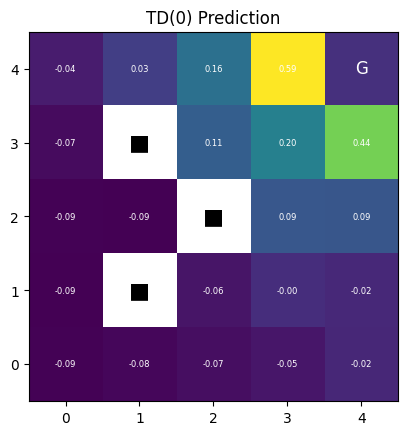

In [6]:
from algorithms import td0_prediction

# 1) TD(0) Configuration
config = RLConfig(gamma=0.9, alpha=0.1, episodes=1000, max_steps=100)
random_policy = random_policy_factory(env.action_space)

# 2) Run TD(0)
start_time = time.time()
V_td = td0_prediction(
    env,
    policy=random_policy,
    num_episodes=config.episodes,
    gamma=config.gamma,
    alpha=config.alpha,
)
elapsed = time.time() - start_time

# 3) Store result
result_td = RLResult(
    name="TD(0) Prediction",
    time_seconds=elapsed,
    iterations=config.episodes,
    value_function=V_td,
    notes="TD(0) with online updates using random policy",
)

print(
    f"Completed in {result_td.iterations} episodes, time = {result_td.time_seconds:.3f}s"
)

# 4) Visualize value function
plot_value_function(result_td.value_function, env, title=result_td.name)
# └───────────────────────────────────────────────────────────────────────────────

## Q-Learning

Completed in 3000 episodes, time = 0.087s
Q-Learning avg reward: 0.93


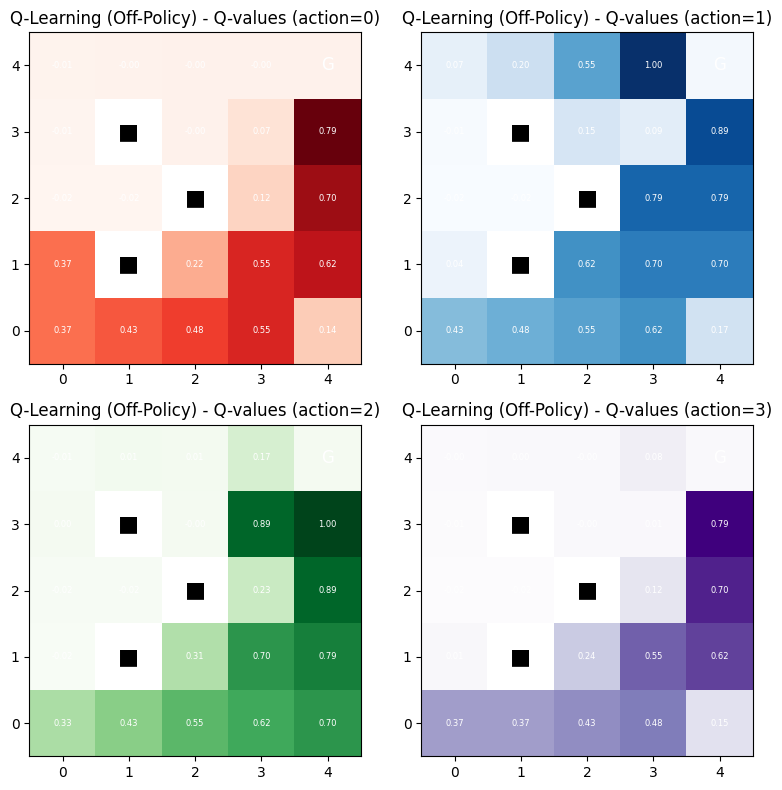

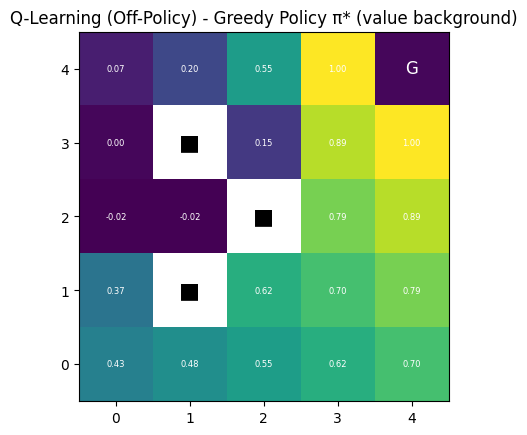

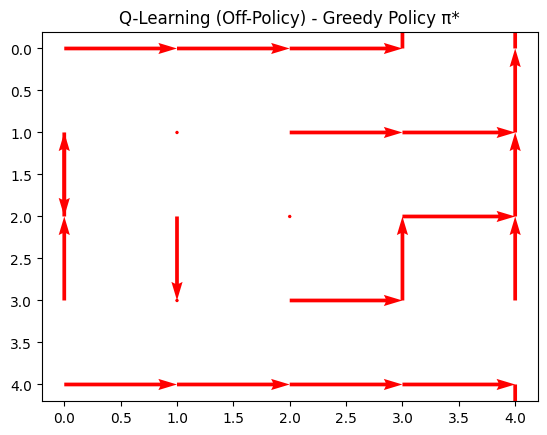

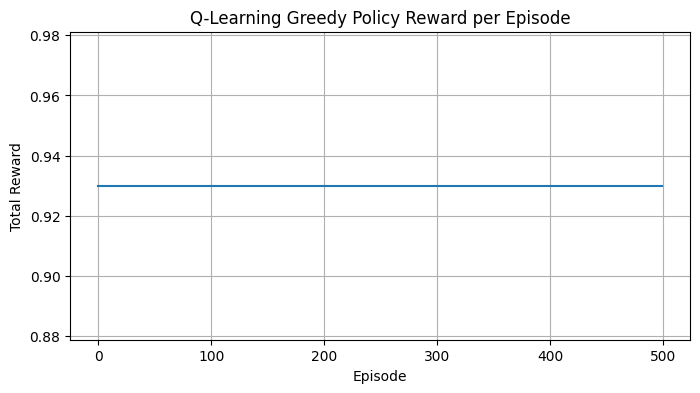

In [7]:
# ┌─── Cell: Q-Learning Control (ε-greedy) ────────────────────────────────────────

from algorithms import q_learning
from utils import plot_q_values, plot_policy_arrows_from_q

# 1) Q-Learning Config
config = RLConfig(gamma=0.9, alpha=0.1, epsilon=0.1, episodes=3000, max_steps=100)

# 2) Run Q-Learning
start_time = time.time()
Q_q = q_learning(
    env,
    num_episodes=config.episodes,
    gamma=config.gamma,
    alpha=config.alpha,
    epsilon=config.epsilon,
)
elapsed = time.time() - start_time

# 3) Store result
result_q = RLResult(
    name="Q-Learning (Off-Policy)",
    time_seconds=elapsed,
    iterations=config.episodes,
    value_function=None,
    q_function=Q_q,
    notes="ε-greedy Q-learning with 3000 episodes",
)

# 2) Q-Learning policy
q_policy = lambda s: max(
    [(a, result_q.q_function[(s, a)]) for a in env.action_space], key=lambda x: x[1]
)[0]
q_rewards, _, _ = record_episode_metrics(env, q_policy, eval_config)
result_q.rewards_per_episode = q_rewards

print(
    f"Completed in {result_q.iterations} episodes, time = {result_q.time_seconds:.3f}s"
)
print(f"Q-Learning avg reward: {np.mean(q_rewards):.2f}")


# 4) Visualize Q-values and derived greedy policy
plot_q_values(result_q.q_function, env, title=result_q.name + " - Q-values")
plot_policy_arrows_from_q(
    result_q.q_function, env, title=result_q.name + " - Greedy Policy π*"
)
plot_episode_rewards(q_rewards, title="Q-Learning Greedy Policy Reward per Episode")

# └───────────────────────────────────────────────────────────────────────────────

## SARSA 

Completed in 3000 episodes, time = 0.070s
SARSA avg reward: 0.93


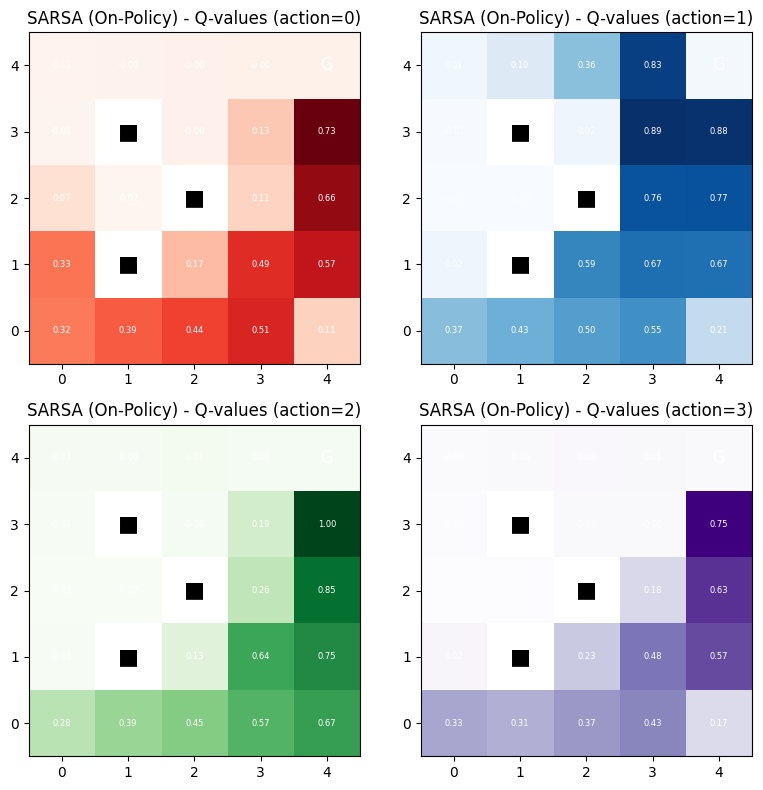

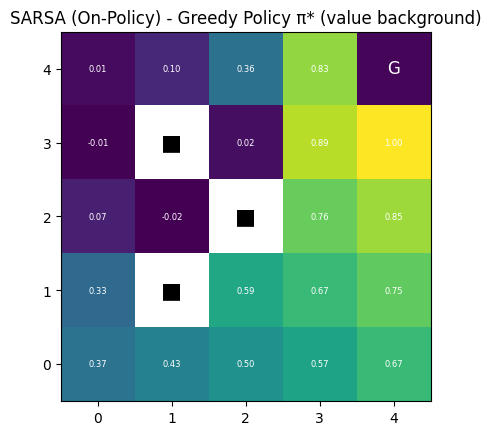

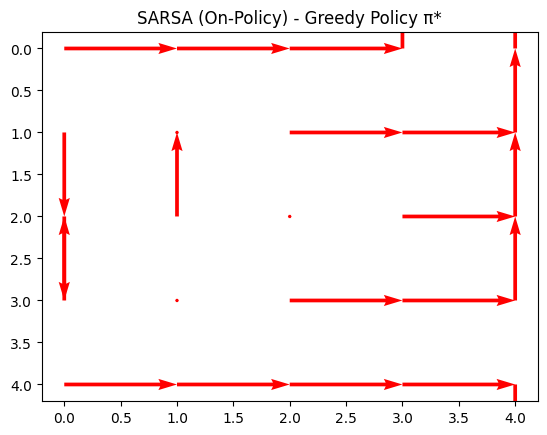

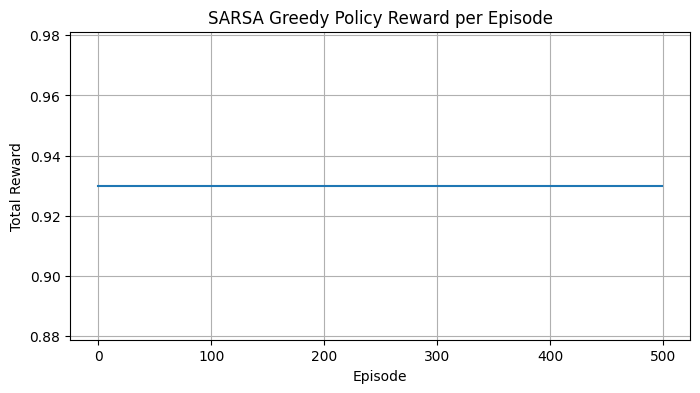

In [8]:
# ┌─── Cell: SARSA Control (ε-greedy) ─────────────────────────────────────────────

from algorithms import sarsa
from utils import plot_q_values, plot_policy_arrows_from_q

# 1) SARSA Config
config = RLConfig(gamma=0.9, alpha=0.1, epsilon=0.1, episodes=3000, max_steps=100)

# 2) Run SARSA
start_time = time.time()
Q_sarsa = sarsa(
    env,
    num_episodes=config.episodes,
    gamma=config.gamma,
    alpha=config.alpha,
    epsilon=config.epsilon,
)
elapsed = time.time() - start_time

# 3) Store result
result_sarsa = RLResult(
    name="SARSA (On-Policy)",
    time_seconds=elapsed,
    iterations=config.episodes,
    value_function=None,
    q_function=Q_sarsa,
    notes="SARSA with ε-greedy exploration over 3000 episodes",
)

# 3) SARSA policy
sarsa_policy = lambda s: max(
    [(a, result_sarsa.q_function[(s, a)]) for a in env.action_space], key=lambda x: x[1]
)[0]
sarsa_rewards, _, _ = record_episode_metrics(env, sarsa_policy, eval_config)
result_sarsa.rewards_per_episode = sarsa_rewards

print(
    f"Completed in {result_sarsa.iterations} episodes, time = {result_sarsa.time_seconds:.3f}s"
)
print(f"SARSA avg reward: {np.mean(sarsa_rewards):.2f}")


# 4) Visualize Q-values and learned greedy policy
plot_q_values(result_sarsa.q_function, env, title=result_sarsa.name + " - Q-values")
plot_policy_arrows_from_q(
    result_sarsa.q_function, env, title=result_sarsa.name + " - Greedy Policy π*"
)
plot_episode_rewards(sarsa_rewards, title="SARSA Greedy Policy Reward per Episode")
# └───────────────────────────────────────────────────────────────────────────────

## TD(λ) with Eligibility Traces

Completed in 1000 episodes, time = 0.502s
TD(λ) avg reward: -1.00


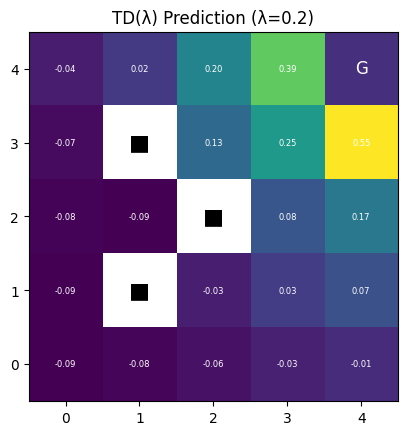

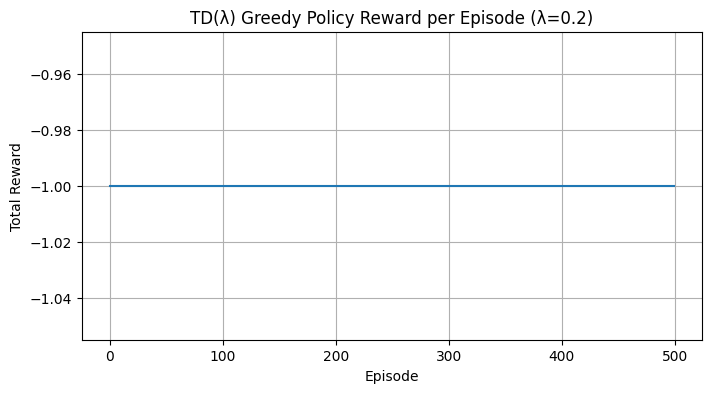

Completed in 1000 episodes, time = 0.522s
TD(λ) avg reward: -1.00


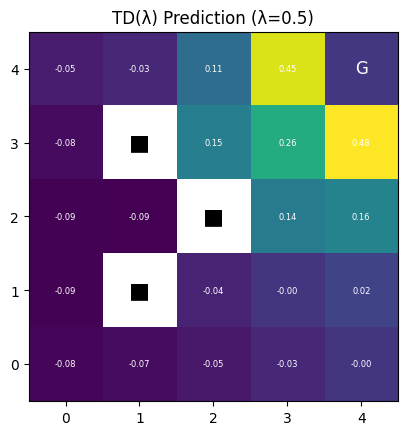

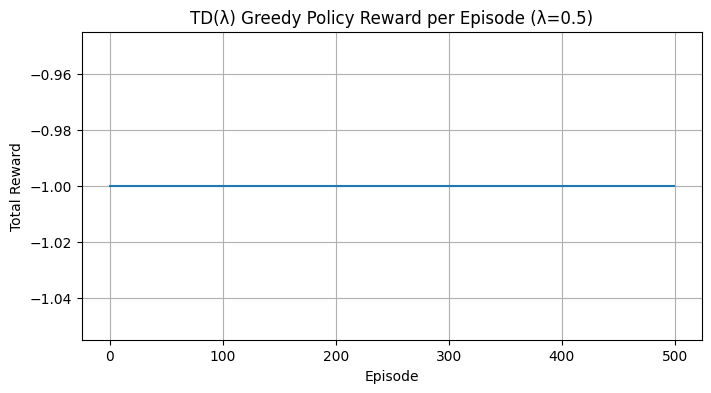

Completed in 1000 episodes, time = 0.504s
TD(λ) avg reward: -1.00


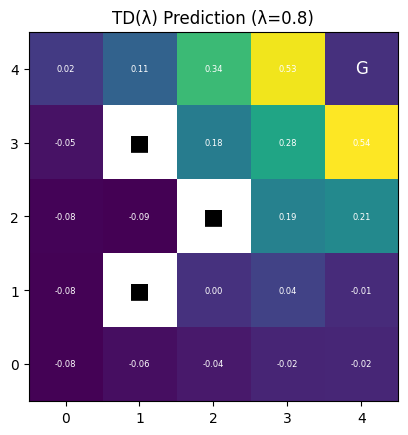

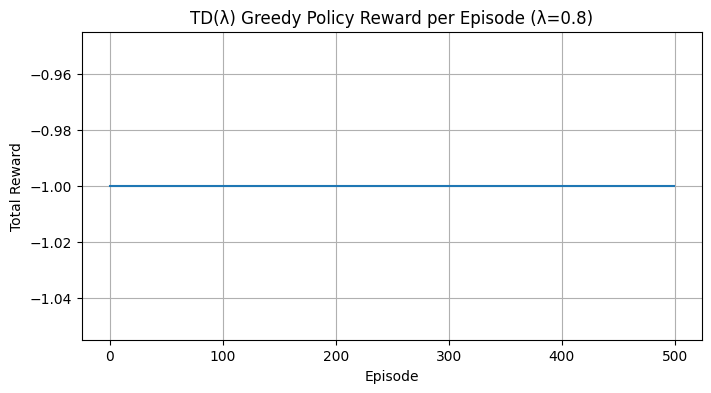

In [9]:
# ┌─── Cell: TD(λ) Prediction (Eligibility Traces) ───────────────────────────────

from algorithms import td_lambda
from utils import plot_value_function

# 1) TD(λ) Config
config = RLConfig(gamma=0.9, alpha=0.1, episodes=1000, max_steps=100)
results_td_lambda = []

# trace decay factor
for i, lambda_ in enumerate([0.2, 0.5, 0.8]):
    # 2) Run TD(λ)
    start_time = time.time()
    V_td_lambda = td_lambda(
        env,
        num_episodes=config.episodes,
        gamma=config.gamma,
        alpha=config.alpha,
        lambda_=lambda_,
    )
    elapsed = time.time() - start_time

    # 3) Store result
    result_td_lambda = RLResult(
        name=f"TD(λ) Prediction (λ={lambda_})",
        time_seconds=elapsed,
        iterations=config.episodes,
        value_function=V_td_lambda,
        notes=f"Backward view TD(λ) with eligibility traces, λ={lambda_}",
    )

    # 4) TD(λ) policy (greedy w.r.t. V)
    tdl_policy = lambda s: max(
        [(a, result_td_lambda.value_function.get(s, 0)) for a in env.action_space],
        key=lambda x: x[1],
    )[0]
    tdl_rewards, _, _ = record_episode_metrics(env, tdl_policy, eval_config)
    result_td_lambda.rewards_per_episode = tdl_rewards

    print(
        f"Completed in {result_td_lambda.iterations} episodes, time = {result_td_lambda.time_seconds:.3f}s"
    )
    print(f"TD(λ) avg reward: {np.mean(tdl_rewards):.2f}")

    # 4) Visualize value function
    plot_value_function(
        result_td_lambda.value_function, env, title=result_td_lambda.name
    )
    plot_episode_rewards(
        tdl_rewards, title=f"TD(λ) Greedy Policy Reward per Episode (λ={lambda_})"
    )
    results_td_lambda.append(result_td_lambda)

# └───────────────────────────────────────────────────────────────────────────────

### Save all RL results experiments to file

In [10]:
import json


def result_to_dict(result):
    def stringify_keys(d):
        return {str(k): v for k, v in d.items()}

    return {
        "name": result.name,
        "time_seconds": result.time_seconds,
        "iterations": result.iterations,
        "value_function": stringify_keys(result.value_function)
        if result.value_function
        else None,
        "q_function": stringify_keys(result.q_function) if result.q_function else None,
        "policy": stringify_keys(result.policy) if result.policy else None,
        "rewards_per_episode": result.rewards_per_episode
        if result.rewards_per_episode
        else None,
        "notes": result.notes,
    }


all_results = [
    result_dp,
    result_mc,
    result_td,
    result_q,
    result_sarsa,
]
all_results.extend(results_td_lambda)

results_dicts = [result_to_dict(r) for r in all_results]
with open("rl_results.json", "w") as f:
    json.dump(results_dicts, f, indent=2)

# Report

| Algorithm            | Time (s) | Iterations | Q-function | Final Value Quality | Notes                                           |
|----------------------|----------|------------|------------|----------------------|-------------------------------------------------|
| Value Iteration (DP) | 0.0093   | 89         | ❌         | High (converged)     | Converged using full environment model          |
| Monte Carlo          | 0.1614   | 1000       | ❌         | Low                  | First-visit MC with random policy               |
| TD(0)                | 0.1339   | 1000       | ❌         | Medium               | Online TD(0) with random policy                 |
| Q-Learning           | 0.0829   | 3000       | ✅         | High Q-values        | ε-greedy Q-learning with 3000 episodes          |
| SARSA                | 0.0722   | 3000       | ✅         | Competitive Q-values | On-policy SARSA with ε-greedy exploration       |
| TD(lambda) (lambda=0.2)        | 0.0776   | 1000       | ✅         | Medium–High          | Eligibility traces, λ=0.2                       |
| TD(lambda) (lambda=0.5)        | 0.0713   | 1000       | ✅         | Medium–High          | Eligibility traces, λ=0.5                       |
| TD(lambda) (lambda=0.8)        | 0.0836   | 1000       | ✅         | Medium–High          | Eligibility traces, λ=0.8                       |

---

### Environment Summary
The environment is a 5x5 GridWorld with obstacles at (1,1), (2,2), and (3,1), and a goal at (4,4). Each move incurs a -0.01 penalty, and reaching the goal yields +1.0. Movement is deterministic. Agents learn from interaction (or model) to optimize policy toward the goal.

---

### Experimental Observations

**Value Iteration (DP):**
- Fastest by iterations and wall time (0.009s).
- Achieved high-value estimates and a precise greedy policy.
- Assumes full knowledge of environment dynamics.

**Monte Carlo:**
- First-visit MC with a random policy.
- Very high variance, leading to unstable and low value estimates.
- No usable policy produced; mostly diagnostic in this run.

**TD(0):**
- Online, model-free, step-wise updates.
- Performed moderately better than Monte Carlo due to lower variance.
- Still reliant on the random policy, resulting in underwhelming convergence.

**Q-Learning:**
- Off-policy with ε-greedy exploration.
- Fast, stable convergence with high Q-values.
- Excellent balance between speed and policy quality.

**SARSA:**
- On-policy version of Q-learning.
- Produced safer and slightly more conservative Q-values.
- Lower variance, solid reward returns.

**TD(lamda):**
- Multi-step TD with eligibility traces. Three configurations tested:
  - lambda=0.2: faster learning, less propagation.
  - lambda=0.5: balanced temporal credit assignment.
  - lambda=0.8: more delayed credit, higher smoothing.
- All performed comparably in terms of final Q-values and reward curves.

---

### Strengths & Limitations

| Algorithm | Strengths | Limitations |
|----------|-----------|-------------|
| **DP** | Fast and precise | Requires full environment model |
| **MC** | Conceptually simple | High variance, policy-free in this setup |
| **TD(0)** | Online, low variance | Limited by behavior policy |
| **Q-Learning** | Finds optimal policy, efficient | Off-policy updates may be unstable in stochastic settings |
| **SARSA** | Stable learning, safer behavior | May converge to suboptimal policy |
| **TD(lambda)** | Better long-term credit assignment | Tuning λ is non-trivial, more computation |

---

## Compare Results

This section evaluates the eight experiment configurations over five criteria, using collected metrics and visualizations.

---

### Convergence

- **Fastest Convergence:**  
  Value Iteration (DP) — converged in 89 iterations and 0.009s.

- **Parameter Sensitivity:**  
  - Higher **γ** slows convergence but promotes farsighted decisions.
  - Higher **α** accelerates updates but increases noise.
  - **lambda** in TD(lambda) improves temporal credit assignment but at a computational cost.

---

### Handling Delayed Rewards

- **Most Effective:**  
  TD(lambda) (especially lambda=0.5 or 0.8) excels in environments where rewards are sparse and require multi-step credit assignment.

- **Comparison:**  
  - TD(0) updates only 1 step → misses longer dependencies.
  - MC waits for full returns → noisy.
  - TD(lambda) balances both, improving generalization over episodes.

---

### Exploration vs. Exploitation

- **Off-policy vs. On-policy:**  
  - **Q-Learning** updates using the best action's Q-value — optimistic and risk-prone.
  - **SARSA** uses the actual action taken — more cautious and stable.

- **SARSA Advantage:**  
  In noisy or risky environments, SARSA’s stability makes it a better fit for safe, robust policy learning.

---

### Computational Complexity

- **Most Efficient:**  
  - DP is fastest overall but infeasible in unknown environments.
  - Among model-free methods, **SARSA** and **Q-Learning** show excellent speed (~0.07–0.08s).

- **TD(lambda) Cost:**  
  Slightly higher memory and runtime (~0.08s), but yields more accurate value propagation.

---

### Policy Quality

- **Best Performers:**  
  - DP (exact).
  - Q-Learning and SARSA produced strong and usable policies with excellent average rewards (~0.93).

- **Suboptimal Preference:**  
  In safety-critical tasks, suboptimal but stable policies (from SARSA or TD(λ)) may be preferred.

---

### Summary Table

| Criterion                     | Best Performer / Insight                                  |
|------------------------------|------------------------------------------------------------|
| **Convergence Speed**        | Value Iteration (DP) — fastest with full model             |
| **Handling Delayed Rewards** | TD(lambda) (lambda=0.5/0.8) — smooth, multi-step credit assignment   |
| **Exploration vs Exploitation** | SARSA is safer; Q-Learning is faster and greedier        |
| **Computational Efficiency** | SARSA / Q-Learning; DP if model known                     |
| **Policy Quality**           | DP = best; Q-Learning ≈ SARSA                             |
| **When Suboptimal is OK**    | SARSA, TD(lambda) for safety-focused applications               |


---

### Conclusion

This assignment demonstrates the spectrum of reinforcement learning approaches — from model-based planning (DP) to sample-efficient control (TD variants). Q-Learning and SARSA consistently performed well in balancing convergence, policy quality, and compute. TD(λ) added nuance in sparse-reward settings. MC and TD(0) were more useful as conceptual baselines than practical solutions in this case.
